# Passive buy and hold strategy
#### Truls 

In [1]:
# Packages. 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
# Fetch data
df=pd.read_csv("../spiff_data-2.csv")

# Fix issue with '1000' values. 
mask=df==1000
df[mask]=pd.NA

# Remove values after row 5255, since they are all NA. 
df=df.iloc[:5255]

df=df.ffill()
df=df.drop(columns=['Unnamed: 0', 'day'])



# Risk free rate
r = 0.03  

In [3]:
def log_returns(portfolie_value, period=1):
    maturity=len(portfolie_value)
    log_returns=np.log(portfolie_value[1:maturity]/portfolie_value[0:maturity-1])

    #annulize 
    log_returns=period*log_returns
    return log_returns
 
def SharpeRatio(log_return, r, period=1, low_volatilty_asset_adjustment=0):

    log_return = np.asarray(log_return)
    log_return=log_return[~np.isnan(log_return)]
    
    mu_hat = np.mean(log_return)
    sigma_hat = np.std(log_return)

    # Add a small epsilon to compensate for near-zero volatility. 
    # This is only used in the grid search optimisation in the channel breakout strategy,
    # where some parameter combinations may lead to very low volatility.
    sigma_hat+=low_volatilty_asset_adjustment

    daily_SharpeRatio=(mu_hat - r/252) / sigma_hat

    # Return SharpeRatio "annualized" to the correct period. 
    return np.sqrt(period)*daily_SharpeRatio

In [4]:
# Evaluate the strategy on all assets, and also on a balanced portfolio and an unweighted portfolio.
results = []

for asset_name in df.columns:
    portfolio_value = df[asset_name].values.astype(float)
    strategy_returns = log_returns(portfolio_value)
    sharpe_ratio = SharpeRatio(strategy_returns, r=r, period=252)
    avg_return = np.mean(strategy_returns) * 252
    std_dev = np.std(strategy_returns) * np.sqrt(252)

    results.append({
        'Asset': asset_name,
        'Sharpe Ratio': sharpe_ratio,
        'Avg Annual Return': avg_return,
        'Annual Std Dev': std_dev
    })



prices = df.to_numpy()
initial_market_price = prices[0,:]
weights=initial_market_price / sum(initial_market_price)
weighted_portfolio_value = prices @ weights
weighted_portfolio_value=weighted_portfolio_value / weighted_portfolio_value[0] # Normalize to 1 at the start, to make it comparable to the other assets.

unweighted_portfolio_value = prices @ np.ones(prices.shape[1])
unweighted_portfolio_value = unweighted_portfolio_value / unweighted_portfolio_value[0] # Normalize to 1 at the start, to make it comparable to the other assets.

weighted_strategy_returns = log_returns(weighted_portfolio_value)
unweighted_strategy_returns = log_returns(unweighted_portfolio_value)

sharpe_ratio_weighted = SharpeRatio(weighted_strategy_returns, r=r, period=252)
sharpe_ratio_unweighted = SharpeRatio(unweighted_strategy_returns, r=r, period=252)
avg_return_weighted = np.mean(weighted_strategy_returns) * 252
avg_return_unweighted = np.mean(unweighted_strategy_returns) * 252
std_dev_weighted = np.std(weighted_strategy_returns) * np.sqrt(252)
std_dev_unweighted = np.std(unweighted_strategy_returns) * np.sqrt(252)

results.append({
    'Asset': "Balanced Portfolio",
   'Sharpe Ratio': sharpe_ratio_weighted,
   'Avg Annual Return': avg_return_weighted,
   'Annual Std Dev': std_dev_weighted
    })

results.append({
    'Asset': "Unweighted Portfolio",
   'Sharpe Ratio': sharpe_ratio_unweighted,
   'Avg Annual Return': avg_return_unweighted,
   'Annual Std Dev': std_dev_unweighted
    })


results_df = pd.DataFrame(results)
print(results_df)

#Get risk-free comaparable asset

risk_free_asset =np.exp(
        (r / 252) * np.arange(0,len(strategy_returns))
    )


                  Asset  Sharpe Ratio  Avg Annual Return  Annual Std Dev
0                gurkor      0.138445           0.038637        0.062385
1               guitars      0.089803           0.051188        0.235938
2            slingshots      0.095992           0.052403        0.233389
3                stocks     -0.224464          -0.023016        0.236188
4                 sugar     -0.155265          -0.007359        0.240613
5                 water      0.157760           0.038763        0.055546
6          tranquillity     -0.043085           0.021405        0.199477
7    Balanced Portfolio     -0.168346           0.013123        0.100252
8  Unweighted Portfolio     -0.088189           0.022403        0.086144


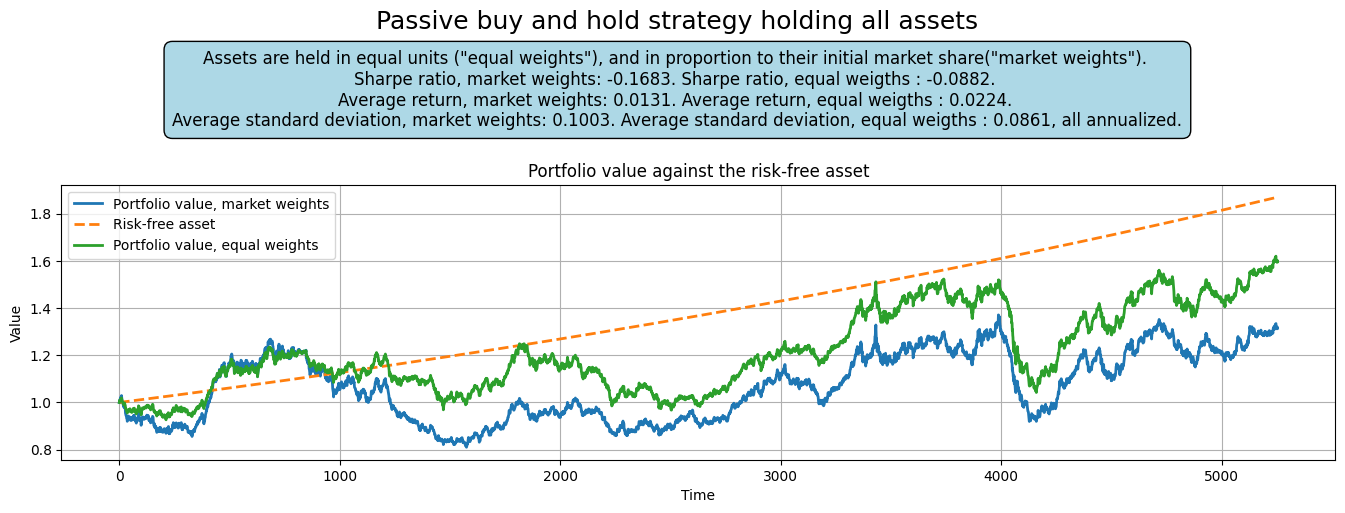

In [6]:
# Plot the two portfolios consisting of all assets. 
nrows =  1  
height_ratios = [3]

fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(nrows, 1, height_ratios=height_ratios, hspace=0.4)

# Title at the top
fig.suptitle("Passive buy and hold strategy holding all assets", fontsize=18)

# Blue box as a figure-level annotation
sharpe_text = (
    "Assets are held in equal units (\"equal weights\"), and in proportion to their initial market share(\"market weights\"). \n"
    f"Sharpe ratio, market weights: {sharpe_ratio_weighted:.4f}. "
    f"Sharpe ratio, equal weigths : {sharpe_ratio_unweighted:.4f}. \n"
    f"Average return, market weights: {np.mean(weighted_strategy_returns) * 252:.4f}. "
    f"Average return, equal weigths : {np.mean(unweighted_strategy_returns) * 252:.4f}. \n"
    f"Average standard deviation, market weights: {np.std(weighted_strategy_returns) * np.sqrt(252):.4f}. "
    f"Average standard deviation, equal weigths : {np.std(unweighted_strategy_returns) * np.sqrt(252):.4f}, all annualized."
)
fig.text(
    0.5, 0.9,
    sharpe_text,
    fontsize=12,
    ha='center',
    va='top',
    multialignment='center',
    bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='round,pad=0.5')
)

# Plot starts lower to make room for the text box
ax1 = fig.add_subplot(gs[0])
ax1.set_position([0.06, 0.08, 0.91, 0.55])
ax1.plot(weighted_portfolio_value, label='Portfolio value, market weights', linewidth=2)
ax1.plot(risk_free_asset, label='Risk-free asset', linestyle='--', linewidth=2)
ax1.plot(unweighted_portfolio_value, label='Portfolio value, equal weights', linewidth=2)
ax1.set_title("Portfolio value against the risk-free asset")
ax1.set_xlabel("Time")
ax1.set_ylabel("Value")
ax1.legend()
ax1.grid(True)


plt.savefig("../ChannelBreakoutPlots/BH1.png")
plt.show()